## Evolution of science across polities and regions

Number of scientists per 50-year bin for four series (2x2 figure):
Chinese World, Muslim World, Mediterranean World, England.

### 1. Setup

In [14]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from collections import Counter

DB = '../data/humans_clean.sqlite3'

### 2. Data extraction

All SQLite3 queries: scientist counts per 50-year bin for each series, and polity period date ranges for figure shading.

In [15]:
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

# Manual mapping: each series → list of polity name patterns (matched with LIKE '%pattern%')
SERIES = [
    ('Chinese World', [
        'Han Dynasty', 'Tang Dynasty', 'Northern Song', 'Southern Song',
        'Yuan Dynasty', 'Ming Dynasty', 'Qing Dynasty', 'Sui Dynasty',
        'Qin Dynasty', 'Shang Dynasty', 'Zhou Dynasty',
        'Western Jin', 'Cao Wei', 'Northern Wei', 'Northern Zhou',
        'Warring States', 'Spring and Autumn', 'Five Dynasties',
        'Liang Dynasty', 'Liu Song Dynasty', 'Eastern Wu',
        'Southern Qi', 'Great Jin', 'Western Wei', 'Western Qin',
        'Later Qin', 'Former Liang', 'Southern Tang', 'Mongol Empire',
    ], None, 1850),
    ('Muslim World', [
        'Abbasid Caliphate', 'Umayyad Caliphate', 'Ottoman Empire',
        'Mamluk Sultanate', 'Great Seljuk Empire', 'Buyid Dynasty',
        'Safavid Dynasty', 'Samanid Empire', 'Timurid Empire',
        'Fatimid Caliphate', 'Almohad Caliphate', 'Ayyubid Sultanate',
        'Ilkhanate', 'Ghaznavid Empire', 'Rashidun Caliphate',
        'Zengid dynasty', 'Saadi Sultanate', 'Beylik of Tunis',
        'Emirate of Diriyah', 'Sasanian Empire', 'Hamdanid Emirates',
        'Zayyanid dynasty', 'Mongol Empire',
    ], 700, 1850),
    ('Mediterranean World', [
        'Greek City-States', 'Roman Republic', 'Roman Empire',
        'Etruscans', 'Macedonian Empire', 'Carthage',
        'Ptolemaic', 'Seleucid', 'Antigonid',
        'Western Roman Empire', 'Eastern Roman Empire',
        'Greek Dark Ages', 'Greek Colonies',
    ], None, 700),
    ('England', [
        'Anglo-Saxon England', 'Kingdom of Wessex', 'Kingdom of Mercia',
        'Kingdom of Northumbria', 'Kingdom of Kent', 'Kingdom of East Anglia',
        'Kingdom of England', 'Norman England', 'Angevin Empire',
        'Commonwealth of England', 'English Colonial Empire',
    ], 500, 1700),
]

results = {}

def bin_and_store(title, years, yr_start, yr_end, clip_start=None, clip_end=None):
    """Bin years into 50-year bins, keep complete bins, store in results."""
    bin_n = Counter()
    for y in years:
        bin_n[((y + 25) // 50) * 50] += 1
    bins = sorted(b for b in bin_n if b - 25 >= yr_start and b + 24 <= yr_end)
    counts = [bin_n[b] for b in bins]
    if clip_start is not None or clip_end is not None:
        pairs = [(b, c) for b, c in zip(bins, counts)
                 if (clip_start is None or b >= clip_start)
                 and (clip_end is None or b <= clip_end)]
        bins, counts = [b for b, _ in pairs], [c for _, c in pairs]
        yr_start = clip_start or yr_start
        yr_end = clip_end or yr_end
    results[title] = dict(bins=bins, counts=counts, yr_start=yr_start, yr_end=yr_end)
    print(f'{title} ({yr_start}\u2013{yr_end}): {sum(counts)} scientists, {len(bins)} bins')

for title, patterns, clip_s, clip_e in SERIES:
    where = " OR ".join(f"c.polity_name LIKE '%{p}%'" for p in patterns)
    yr_start, yr_end = conn.execute(f'''
        SELECT MIN(c.impact_year), MAX(c.impact_year) FROM consolidate c
        WHERE ({where}) AND c.impact_year IS NOT NULL
    ''').fetchone()
    years = [r[1] for r in conn.execute(f'''
        SELECT DISTINCT c.wikidata_id, c.impact_year FROM consolidate c
        WHERE ({where}) AND c.impact_year IS NOT NULL AND c.is_scientist = 1
    ''')]
    bin_and_store(title, years, yr_start, yr_end, clip_s, clip_e)

# Period shading: polity → region mapping (manual), dates from DB
def get_polity_period(name):
    row = conn.execute('''
        SELECT MIN(pp.from_year), MAX(pp.to_year)
        FROM polities_cliopatria pc
        JOIN cliopatria_polity_periods pp ON pc.id = pp.polity_id
        WHERE pc.name = ?
    ''', (name,)).fetchone()
    return row if row and row[0] is not None else None

REGION_POLITIES = {
    'Chinese World': ['Han Dynasty', 'Tang Dynasty', 'Northern Song', 'Southern Song',
                       'Yuan Dynasty', 'Ming Dynasty', 'Qing Dynasty'],
    'Muslim World': ['Rashidun Caliphate', 'Umayyad Caliphate', 'Abbasid Caliphate',
                      'Fatimid Caliphate', 'Great Seljuk Empire', 'Ayyubid Sultanate',
                      'Mamluk Sultanate', 'Timurid Empire', 'Safavid Dynasty',
                      'Ottoman Empire'],
    'Mediterranean World': ['Greek City-States', 'Roman Republic', 'Roman Empire',
                             'Macedonian Empire', 'Ptolemaic Kingdom', 'Eastern Roman Empire'],
    'England': ['Anglo-Saxon England', 'Kingdom of Wessex', 'Kingdom of England',
                'Norman England', 'Angevin Empire', 'Commonwealth of England'],
}

PERIODS = {}
for region, polity_names in REGION_POLITIES.items():
    PERIODS[region] = []
    for name in polity_names:
        period = get_polity_period(name)
        if period:
            label = 'Song' if name in ('Northern Song', 'Southern Song') else name
            if label == 'Song' and PERIODS[region] and PERIODS[region][-1][0] == 'Song':
                prev = PERIODS[region][-1]
                PERIODS[region][-1] = ('Song', prev[1], period[1])
            else:
                PERIODS[region].append((label, period[0], period[1]))
    for name, start, end in PERIODS[region]:
        print(f'  {region} > {name}: {start}\u2013{end}')

conn.close()

Chinese World (-1600–1850): 1112 scientists, 50 bins
Muslim World (700–1850): 2524 scientists, 24 bins
Mediterranean World (-1000–700): 714 scientists, 28 bins
England (500–1700): 1367 scientists, 20 bins
  Chinese World > Han Dynasty: -202–237
  Chinese World > Tang Dynasty: 623–910
  Chinese World > Song: 961–1278
  Chinese World > Yuan Dynasty: 1294–1374
  Chinese World > Ming Dynasty: 1375–1644
  Chinese World > Qing Dynasty: 1645–1911
  Muslim World > Rashidun Caliphate: 633–665
  Muslim World > Umayyad Caliphate: 656–756
  Muslim World > Abbasid Caliphate: 750–1259
  Muslim World > Fatimid Caliphate: 911–1176
  Muslim World > Great Seljuk Empire: 1040–1201
  Muslim World > Ayyubid Sultanate: 1177–1249
  Muslim World > Mamluk Sultanate: 1241–1518
  Muslim World > Timurid Empire: 1375–1506
  Muslim World > Safavid Dynasty: 1502–1737
  Muslim World > Ottoman Empire: 1305–1923
  Mediterranean World > Greek City-States: -800–83
  Mediterranean World > Roman Republic: -500–-32
  Medite

In [16]:
rows = []
for title in results:
    d = results[title]
    for b, c in zip(d['bins'], d['counts']):
        rows.append({'series': title, 'bin': b, 'scientists': c})

df_evolution = pd.DataFrame(rows)
print(f"Scientists per 50-year bin for {len(results)} series:")
display(df_evolution)

rows_p = []
for region, periods in PERIODS.items():
    for name, start, end in periods:
        rows_p.append({'region': region, 'polity': name, 'from_year': start, 'to_year': end})

df_periods = pd.DataFrame(rows_p)
print(f"\nPolity periods for figure shading ({len(df_periods)} entries):")
df_periods

Scientists per 50-year bin for 4 series:


,series,bin,scientists
0,Chinese World,-700,1
1,Chinese World,-550,1
2,Chinese World,-500,4
3,Chinese World,-450,3
4,Chinese World,-400,5
...,...,...,...
117,England,1500,35
118,England,1550,125
119,England,1600,275
120,England,1650,410



Polity periods for figure shading (28 entries):


,region,polity,from_year,to_year
0,Chinese World,Han Dynasty,-202,237
1,Chinese World,Tang Dynasty,623,910
2,Chinese World,Song,961,1278
3,Chinese World,Yuan Dynasty,1294,1374
4,Chinese World,Ming Dynasty,1375,1644
5,Chinese World,Qing Dynasty,1645,1911
6,Muslim World,Rashidun Caliphate,633,665
7,Muslim World,Umayyad Caliphate,656,756
8,Muslim World,Abbasid Caliphate,750,1259
9,Muslim World,Fatimid Caliphate,911,1176


### 3. Figure

2x2 grid with log y-axis. Dynasty/period shading is overlaid where applicable.

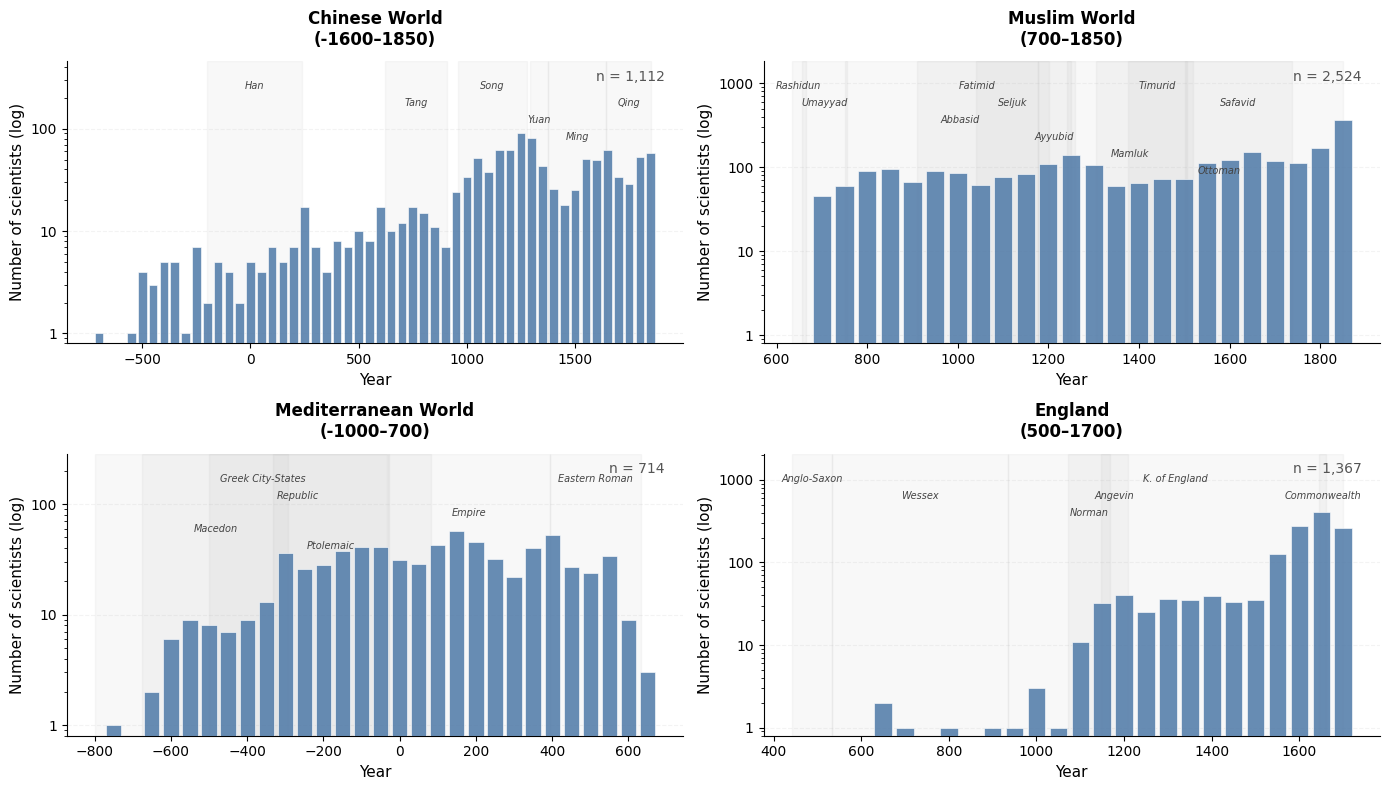

In [17]:
import matplotlib.ticker as ticker

COLOR_BAR = '#4e79a7'
panel_order = ['Chinese World', 'Muslim World', 'Mediterranean World', 'England']

# Shorten long polity names for labels
SHORT_LABELS = {
    'Han Dynasty': 'Han', 'Tang Dynasty': 'Tang', 'Yuan Dynasty': 'Yuan',
    'Ming Dynasty': 'Ming', 'Qing Dynasty': 'Qing',
    'Rashidun Caliphate': 'Rashidun', 'Umayyad Caliphate': 'Umayyad',
    'Abbasid Caliphate': 'Abbasid', 'Fatimid Caliphate': 'Fatimid',
    'Great Seljuk Empire': 'Seljuk', 'Ayyubid Sultanate': 'Ayyubid',
    'Mamluk Sultanate': 'Mamluk', 'Timurid Empire': 'Timurid',
    'Safavid Dynasty': 'Safavid', 'Ottoman Empire': 'Ottoman',
    'Roman Republic': 'Republic', 'Roman Empire': 'Empire',
    'Macedonian Empire': 'Macedon', 'Ptolemaic Kingdom': 'Ptolemaic',
    'Eastern Roman Empire': 'Eastern Roman',
    'Greek City-States': 'Greek City-States',
    'Anglo-Saxon England': 'Anglo-Saxon', 'Kingdom of Wessex': 'Wessex',
    'Kingdom of England': 'K. of England',
    'Norman England': 'Norman', 'Angevin Empire': 'Angevin',
    'Commonwealth of England': 'Commonwealth',
}

def assign_y_levels(periods, yr_end, x_range, n_levels=6):
    """Assign y-levels to period labels so overlapping labels sit on different rows."""
    padding = x_range * 0.08
    levels = [[] for _ in range(n_levels)]
    y_values = [0.93 - i * 0.06 for i in range(n_levels)]
    assignments = []
    for name, start, end in periods:
        clipped = min(end, yr_end)
        label = SHORT_LABELS.get(name, name)
        s_pad, e_pad = start - padding, clipped + padding
        for lvl in range(n_levels):
            if all(e_pad < s or s_pad > e for s, e in levels[lvl]):
                levels[lvl].append((s_pad, e_pad))
                assignments.append((label, start, clipped, y_values[lvl]))
                break
        else:
            assignments.append((label, start, clipped, y_values[-1]))
    return assignments

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, title in zip(axes.flatten(), panel_order):
    d = results[title]
    ax.bar(d['bins'], d['counts'], width=40, color=COLOR_BAR, edgecolor='white',
           linewidth=0.5, alpha=0.85, zorder=3)
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}' if x >= 1 else ''))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_ylabel('Number of scientists (log)', fontsize=11)
    if d['counts']:
        ax.set_ylim(bottom=0.8, top=max(d['counts']) * 5)
    ax.set_xlabel('Year', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.15, linestyle='--')
    ax.set_title(f"{title}\n({d['yr_start']}\u2013{d['yr_end']})",
                 fontsize=12, fontweight='bold', pad=12)
    ax.text(0.97, 0.97, f"n = {sum(d['counts']):,}", transform=ax.transAxes,
            fontsize=10, color='#555555', ha='right', va='top')

    blended = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    x_range = d['yr_end'] - d['yr_start']
    for label, start, clipped, y in assign_y_levels(PERIODS.get(title, []), d['yr_end'], x_range):
        ax.axvspan(start, clipped, alpha=0.06, color='#888', zorder=1)
        ax.text((start + clipped) / 2, y, label, transform=blended,
                ha='center', va='top', fontsize=7, color='#444', style='italic')

plt.tight_layout()
plt.show()